In [1]:
!pip install --upgrade scikit-learn==1.9.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
# ============================================
# STEP 1: Mount Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================
# STEP 2: Import Required Libraries
# ============================================

# For data handling
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# For saving models
import joblib
import os

# Ignore harmless warnings for a cleaner notebook
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# ============================================
# STEP 3: Load Dataset from Google Drive
# ============================================

file_path = '/content/drive/MyDrive/Machine Learning Projects/fda_adverse_events_cancer_cardio.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (13955, 9)


In [5]:
# ============================================
# STEP 4: Initial Dataset Inspection
# ============================================

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
df.head()
print("Dataset Info:")
df.info()
print("Missing Values per Column:")
df.isnull().sum().sort_values(ascending=False)

Dataset Shape: (13955, 9)

First 5 Rows:
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13955 entries, 0 to 13954
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Safety_Report_ID  13955 non-null  object 
 1   Receipt_Date      13955 non-null  int64  
 2   Patient_Sex       13361 non-null  object 
 3   Patient_Age       8134 non-null   float64
 4   Drug_Name         13955 non-null  object 
 5   Drug_Indication   13955 non-null  object 
 6   Reactions         13955 non-null  object 
 7   Seriousness       0 non-null      float64
 8   Fatal             13955 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 981.3+ KB
Missing Values per Column:


,0
Seriousness,13955
Patient_Age,5821
Patient_Sex,594
Safety_Report_ID,0
Receipt_Date,0
Drug_Name,0
Drug_Indication,0
Reactions,0
Fatal,0


In [6]:
# ============================================
# STEP 4.5: Drop Empty Column + Investigate Target & Age
# ============================================
df = df.drop(columns=['Seriousness'])

print("Fatal value counts:")
print(df['Fatal'].value_counts())

print("\nPatient_Age summary (including the anomaly):")
print(df['Patient_Age'].describe())

print("\nHow many ages > 120 (impossible for a human):")
print((df['Patient_Age'] > 120).sum())

Fatal value counts:
Fatal
No     11703
Yes     2252
Name: count, dtype: int64

Patient_Age summary (including the anomaly):
count     8134.000000
mean       411.084583
std       2860.607129
min          0.000000
25%         55.000000
50%         66.000000
75%         75.000000
max      33529.000000
Name: Patient_Age, dtype: float64

How many ages > 120 (impossible for a human):
175


In [7]:
# ============================================
# STEP 4.6: Test the "Age in Days" Hypothesis
# ============================================
# If ages > 120 are actually in days, dividing by 365 should give plausible values

anomalous_ages = df[df['Patient_Age'] > 120]['Patient_Age']
print("Sample of anomalous ages, converted as if they were days:")
print((anomalous_ages / 365).describe())

print("\nA few examples side-by-side:")
print(pd.DataFrame({
    'Original (assumed days)': anomalous_ages.head(10),
    'Converted (years)': (anomalous_ages / 365).head(10).round(1)
}))

Sample of anomalous ages, converted as if they were days:
count    175.000000
mean      44.395820
std       30.765174
min        0.408219
25%        2.408219
50%       55.342466
75%       68.861644
max       91.860274
Name: Patient_Age, dtype: float64

A few examples side-by-side:
     Original (assumed days)  Converted (years)
7                      930.0                2.5
35                     822.0                2.3
92                     877.0                2.4
130                  23642.0               64.8
232                    528.0                1.4
387                    779.0                2.1
629                  27450.0               75.2
648                  21601.0               59.2
653                  30654.0               84.0
813                    691.0                1.9


In [8]:
# ============================================
# STEP 4.7: Fix Age Unit Inconsistency (Days -> Years)
# ============================================
df.loc[df['Patient_Age'] > 120, 'Patient_Age'] = df.loc[df['Patient_Age'] > 120, 'Patient_Age'] / 365

print("Age anomalies fixed. New summary:")
print(df['Patient_Age'].describe())
print(f"\nAny remaining ages > 120: {(df['Patient_Age'] > 120).sum()}")

Age anomalies fixed. New summary:
count    8134.000000
mean       63.406475
std        15.970435
min         0.000000
25%        55.000000
50%        65.000000
75%        75.000000
max       100.000000
Name: Patient_Age, dtype: float64

Any remaining ages > 120: 0


Fatal Value Counts:
Fatal
No     11703
Yes     2252
Name: count, dtype: int64

Fatal Class Percentage:
Fatal
No     83.862415
Yes    16.137585
Name: proportion, dtype: float64


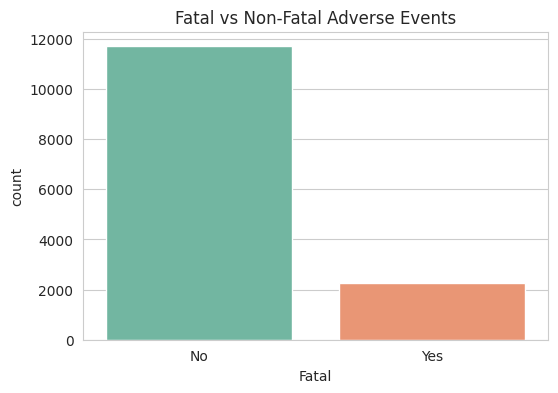

In [9]:
# ============================================
# STEP 5.1: Target Class Distribution
# ============================================
print("Fatal Value Counts:")
print(df['Fatal'].value_counts())
print("\nFatal Class Percentage:")
print(df['Fatal'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Fatal', data=df, palette='Set2')
plt.title('Fatal vs Non-Fatal Adverse Events')
plt.show()

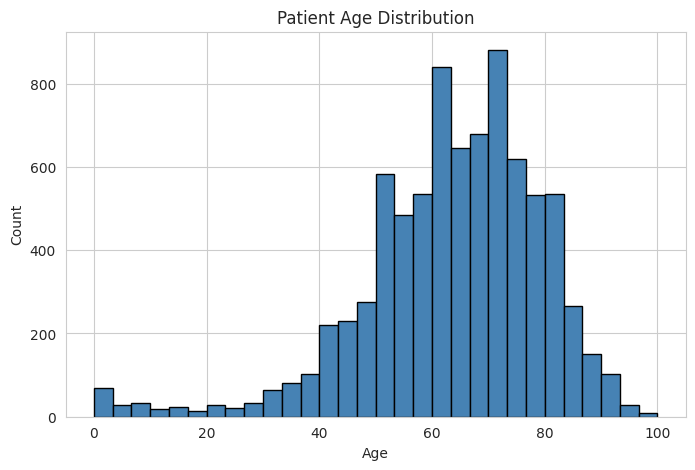

        count       mean        std  min   25%   50%   75%    max
Fatal                                                            
No     6908.0  63.069630  16.015568  0.0  54.0  65.0  74.0  100.0
Yes    1226.0  65.304458  15.584549  0.0  57.0  67.0  76.0   97.0


In [10]:
# ============================================
# STEP 5.2: Age Distribution (Histogram) + Fatal vs Non-Fatal Comparison
# ============================================
df['Patient_Age'].hist(bins=30, figsize=(8,5), color='steelblue', edgecolor='black')
plt.title('Patient Age Distribution')
plt.xlabel('Age'); plt.ylabel('Count')
plt.savefig('fda_age_histogram.png', dpi=150)
plt.show()

print(df.groupby('Fatal')['Patient_Age'].describe())

In [11]:
# ============================================
# STEP 5.3: Categorical Cardinality Check
# ============================================
# This tells us how many unique values each categorical column has —
# critical for deciding encoding strategy (especially Drug_Name, which
# I suspect has very high cardinality based on the dataset preview)

for col in ['Patient_Sex', 'Drug_Name', 'Drug_Indication', 'Reactions']:
    print(f"{col}: {df[col].nunique()} unique values")

Patient_Sex: 3 unique values
Drug_Name: 1751 unique values
Drug_Indication: 255 unique values
Reactions: 10683 unique values


In [12]:
# ============================================
# STEP 5.4: Check Patient_Sex Categories
# ============================================
print(df['Patient_Sex'].value_counts())

Patient_Sex
Female    7807
Male      5553
0            1
Name: count, dtype: int64


In [13]:
# ============================================
# STEP 5.5: Age Outlier Detection (IQR method)
# ============================================
Q1 = df['Patient_Age'].quantile(0.25)
Q3 = df['Patient_Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Patient_Age'] < lower_bound) | (df['Patient_Age'] > upper_bound)]
print(f"Age: {len(outliers)} outliers (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

Age: 218 outliers (bounds: 25.00 to 105.00)


In [14]:
# ============================================
# STEP 6.1: Fix the Bad Patient_Sex Value
# ============================================
# The single "0" value is a data entry error, not a real category
df['Patient_Sex'] = df['Patient_Sex'].replace('0', np.nan)
print("Patient_Sex value counts after fix:")
print(df['Patient_Sex'].value_counts(dropna=False))

Patient_Sex value counts after fix:
Patient_Sex
Female    7807
Male      5553
NaN        595
Name: count, dtype: int64


In [15]:
# ============================================
# STEP 6.2: Handle Missing Values
# ============================================
# Patient_Sex (594 + 1 bad value): impute with mode (most common category)
df['Patient_Sex'] = df['Patient_Sex'].fillna(df['Patient_Sex'].mode()[0])

# Patient_Age (41.7% missing): impute with median.
# This is a large chunk of missing data — median is still our safest choice
# (robust to the skew/outliers we just examined), though worth noting in
# your report as a real limitation (41.7% imputed is substantial).
df['Patient_Age'] = df['Patient_Age'].fillna(df['Patient_Age'].median())

print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
Safety_Report_ID    0
Receipt_Date        0
Patient_Sex         0
Patient_Age         0
Drug_Name           0
Drug_Indication     0
Reactions           0
Fatal               0
dtype: int64


In [16]:
# ============================================
# STEP 6.3: Check for Duplicate Rows
# ============================================
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 4


In [17]:
# ============================================
# STEP 6.4: Investigate Duplicates Before Deciding
# ============================================
dup_rows = df[df.duplicated(keep=False)]
print("Fatal distribution among duplicate rows:")
print(dup_rows['Fatal'].value_counts(normalize=True) * 100)

print("\nFatal distribution in full dataset:")
print(df['Fatal'].value_counts(normalize=True) * 100)



Fatal distribution among duplicate rows:
Fatal
No     75.0
Yes    25.0
Name: proportion, dtype: float64

Fatal distribution in full dataset:
Fatal
No     83.862415
Yes    16.137585
Name: proportion, dtype: float64


In [18]:
# ============================================
# STEP 6.5: Drop Duplicate Rows
# ============================================
print(f"Shape before: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after: {df.shape}")
print(f"\nNew Fatal ratio:\n{df['Fatal'].value_counts(normalize=True)*100}")

Shape before: (13955, 8)
Shape after: (13951, 8)

New Fatal ratio:
Fatal
No     83.864956
Yes    16.135044
Name: proportion, dtype: float64


In [19]:
# ============================================
# STEP 7.1: Engineer Features from Reactions
# ============================================
# Reactions is a pipe-separated list (e.g. "COUGH | FATIGUE | DEATH").
# We extract useful numeric/binary signals instead of using raw text.

# Count how many distinct reactions were reported per case
df['Reaction_Count'] = df['Reactions'].apply(lambda x: len(str(x).split('|')))

# Flag if "DEATH" appears explicitly in the reaction text
# (Careful: this could be a strong predictor of Fatal, close to leakage —
# we'll check its correlation with Fatal before deciding to keep it)
df['Has_Death_Reaction'] = df['Reactions'].str.contains('DEATH', case=False, na=False).astype(int)

print(df[['Reaction_Count', 'Has_Death_Reaction']].describe())
print(f"\nHas_Death_Reaction vs Fatal crosstab:")
print(pd.crosstab(df['Has_Death_Reaction'], df['Fatal']))

       Reaction_Count  Has_Death_Reaction
count    13951.000000        13951.000000
mean         3.926744            0.054906
std          4.762271            0.227806
min          1.000000            0.000000
25%          1.000000            0.000000
50%          3.000000            0.000000
75%          5.000000            0.000000
max        100.000000            1.000000

Has_Death_Reaction vs Fatal crosstab:
Fatal                  No   Yes
Has_Death_Reaction             
0                   11686  1499
1                      14   752


In [20]:
# ============================================
# STEP 7.2: Drop Has_Death_Reaction (leakage risk)
# ============================================
df = df.drop(columns=['Has_Death_Reaction', 'Reactions'])
# Also dropping raw 'Reactions' text now that we've extracted Reaction_Count from it

print(f"Shape: {df.shape}")
print(df.columns.tolist())

Shape: (13951, 8)
['Safety_Report_ID', 'Receipt_Date', 'Patient_Sex', 'Patient_Age', 'Drug_Name', 'Drug_Indication', 'Fatal', 'Reaction_Count']


In [21]:
# ============================================
# STEP 7.3: Bucket High-Cardinality Columns (Top N + Other)
# ============================================
# Drug_Name (1,751 unique) and Drug_Indication (255 unique) are too high-cardinality
# for direct one-hot encoding. We keep the most frequent categories and group
# the rest into "Other" — preserves signal from common drugs/conditions while
# keeping the feature space manageable.

TOP_N_DRUGS = 15
TOP_N_INDICATIONS = 15

top_drugs = df['Drug_Name'].value_counts().nlargest(TOP_N_DRUGS).index
df['Drug_Name_Grouped'] = df['Drug_Name'].apply(lambda x: x if x in top_drugs else 'Other')

top_indications = df['Drug_Indication'].value_counts().nlargest(TOP_N_INDICATIONS).index
df['Drug_Indication_Grouped'] = df['Drug_Indication'].apply(lambda x: x if x in top_indications else 'Other')

print("Drug_Name_Grouped value counts:")
print(df['Drug_Name_Grouped'].value_counts())
print("\nDrug_Indication_Grouped value counts:")
print(df['Drug_Indication_Grouped'].value_counts())

# Drop the original high-cardinality columns and the ID/date columns (not predictive features)
df = df.drop(columns=['Drug_Name', 'Drug_Indication', 'Safety_Report_ID', 'Receipt_Date'])
print(f"\nShape after feature engineering: {df.shape}")

Drug_Name_Grouped value counts:
Drug_Name_Grouped
Other          10646
TRACLEER         587
LISINOPRIL       444
LETAIRIS         361
AMLODIPINE       239
DIOVAN           231
ATENOLOL         197
NORVASC          168
NEXAVAR          156
REMODULIN        153
IBRANCE          142
AVASTIN          142
TYKERB           141
ERBITUX          120
OPSUMIT          116
LISINOPRIL.      108
Name: count, dtype: int64

Drug_Indication_Grouped value counts:
Drug_Indication_Grouped
HYPERTENSION                       5384
Other                              2844
PULMONARY ARTERIAL HYPERTENSION    1514
BREAST CANCER                      1169
PROSTATE CANCER                     474
NON-SMALL CELL LUNG CANCER          447
CARDIAC DISORDER                    345
BREAST CANCER METASTATIC            297
BREAST CANCER FEMALE                242
HEPATIC NEOPLASM MALIGNANT          204
PULMONARY HYPERTENSION              198
CARDIAC FAILURE                     176
OVARIAN CANCER                      173
LUNG 

In [22]:
# ============================================
# STEP 7.4: Fix Duplicate Drug Name (trailing period inconsistency)
# ============================================
# We need to go back to the original Drug_Name column to fix this properly,
# so let's redo the bucketing step with this cleaned first.

# Since we already dropped Drug_Name, let's check — did this duplication
# affect Drug_Name_Grouped too? Let's clean it there directly.
df['Drug_Name_Grouped'] = df['Drug_Name_Grouped'].str.rstrip('.')

print("Drug_Name_Grouped value counts after fix:")
print(df['Drug_Name_Grouped'].value_counts())

Drug_Name_Grouped value counts after fix:
Drug_Name_Grouped
Other         10646
TRACLEER        587
LISINOPRIL      552
LETAIRIS        361
AMLODIPINE      239
DIOVAN          231
ATENOLOL        197
NORVASC         168
NEXAVAR         156
REMODULIN       153
AVASTIN         142
IBRANCE         142
TYKERB          141
ERBITUX         120
OPSUMIT         116
Name: count, dtype: int64


In [23]:
# ============================================
# STEP 8: Encode Categorical Variables
# ============================================
# Patient_Sex, Fatal: 2 categories each -> Label Encoding
# Drug_Name_Grouped, Drug_Indication_Grouped: many categories, no order -> One-Hot Encoding

le_sex = LabelEncoder()
df['Patient_Sex'] = le_sex.fit_transform(df['Patient_Sex'])

le_fatal = LabelEncoder()
df['Fatal'] = le_fatal.fit_transform(df['Fatal'])
print("Fatal mapping:", dict(zip(le_fatal.classes_, le_fatal.transform(le_fatal.classes_))))

df = pd.get_dummies(df, columns=['Drug_Name_Grouped', 'Drug_Indication_Grouped'],
                     prefix=['Drug', 'Indication'])

print(f"\nShape after encoding: {df.shape}")
print(df.columns.tolist())

Fatal mapping: {'No': np.int64(0), 'Yes': np.int64(1)}

Shape after encoding: (13951, 35)
['Patient_Sex', 'Patient_Age', 'Fatal', 'Reaction_Count', 'Drug_AMLODIPINE', 'Drug_ATENOLOL', 'Drug_AVASTIN', 'Drug_DIOVAN', 'Drug_ERBITUX', 'Drug_IBRANCE', 'Drug_LETAIRIS', 'Drug_LISINOPRIL', 'Drug_NEXAVAR', 'Drug_NORVASC', 'Drug_OPSUMIT', 'Drug_Other', 'Drug_REMODULIN', 'Drug_TRACLEER', 'Drug_TYKERB', 'Indication_BREAST CANCER', 'Indication_BREAST CANCER FEMALE', 'Indication_BREAST CANCER METASTATIC', 'Indication_CARDIAC DISORDER', 'Indication_CARDIAC FAILURE', 'Indication_COLON CANCER', 'Indication_COLORECTAL CANCER', 'Indication_HEPATIC NEOPLASM MALIGNANT', 'Indication_HYPERTENSION', 'Indication_LUNG NEOPLASM MALIGNANT', 'Indication_NON-SMALL CELL LUNG CANCER', 'Indication_OVARIAN CANCER', 'Indication_Other', 'Indication_PROSTATE CANCER', 'Indication_PULMONARY ARTERIAL HYPERTENSION', 'Indication_PULMONARY HYPERTENSION']


In [24]:
# ============================================
# STEP 6.5: Drop Duplicate Rows (correctly placed)
# ============================================
print(f"Shape before: {df.shape}")
df = df.drop_duplicates()
print(f"Shape after: {df.shape}")
print(f"\nNew Fatal ratio:\n{df['Fatal'].value_counts(normalize=True)*100}")

Shape before: (13951, 35)
Shape after: (6130, 35)

New Fatal ratio:
Fatal
0    78.613377
1    21.386623
Name: proportion, dtype: float64


In [25]:
# ============================================
# STEP 9-11: Correlation, Split, Scale (on deduplicated data)
# ============================================
X = df.drop(columns=['Fatal'])
y = df['Fatal']

print("Top correlations with Fatal:")
print(X.corrwith(y).sort_values(ascending=False).head(10))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nX_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")
print(f"Train ratio:\n{y_train.value_counts(normalize=True)*100}")

Top correlations with Fatal:
Indication_HEPATIC NEOPLASM MALIGNANT    0.104903
Patient_Sex                              0.090114
Drug_NEXAVAR                             0.088127
Patient_Age                              0.083084
Indication_Other                         0.065936
Indication_PULMONARY HYPERTENSION        0.057568
Indication_LUNG NEOPLASM MALIGNANT       0.051436
Drug_LETAIRIS                            0.040365
Indication_NON-SMALL CELL LUNG CANCER    0.038799
Drug_AVASTIN                             0.037200
dtype: float64

X_train: (4904, 34), X_test: (1226, 34)
Train ratio:
Fatal
0    78.609299
1    21.390701
Name: proportion, dtype: float64


In [26]:
# ============================================
# STEP 12-13: Initialize + Train Baseline Models
# ============================================
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

baseline_results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    baseline_results.append({
        'Model': name, 'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    print(f"{name} done.")

baseline_df = pd.DataFrame(baseline_results).sort_values(by='F1-Score', ascending=False)
print("\n=== Baseline Results ===")
baseline_df

Logistic Regression done.
KNN done.
Naive Bayes done.
Decision Tree done.
Random Forest done.
SVM done.
Gradient Boosting done.
AdaBoost done.

=== Baseline Results ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.620718,0.308851,0.625954,0.413619,0.670037
2,Naive Bayes,0.608483,0.302536,0.637405,0.410319,0.653877
5,SVM,0.601958,0.298932,0.641221,0.407767,0.667693
4,Random Forest,0.602773,0.179487,0.240458,0.205546,0.507885
3,Decision Tree,0.601142,0.146417,0.179389,0.161235,0.447846
1,KNN,0.734095,0.219298,0.095420,0.132979,0.533920
6,Gradient Boosting,0.779772,0.214286,0.011450,0.021739,0.675569
7,AdaBoost,0.786297,0.000000,0.000000,0.000000,0.634029


In [27]:
# ============================================
# STEP 14.0: Define Hyperparameter Grids
# ============================================
param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']},
    'KNN': {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']},
    'Naive Bayes': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]},
    'Decision Tree': {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]},
    'AdaBoost': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}
}
print("Hyperparameter grids defined.")

Hyperparameter grids defined.


In [28]:
# ============================================
# STEP 14: Hyperparameter Tuning with GridSearchCV
# ============================================
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_models = {}
tuned_results = []

for name, model in models.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(model, param_grids[name], scoring='f1', cv=cv_strategy, n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)
    best_model = grid_search.best_estimator_
    tuned_models[name] = best_model

    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    tuned_results.append({
        'Model': name, 'Best Params': grid_search.best_params_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    print(f"  Done. Best F1 (CV): {grid_search.best_score_:.4f}")

tuned_df = pd.DataFrame(tuned_results).sort_values(by='F1-Score', ascending=False)
print("\n=== Tuned Results ===")
tuned_df

Tuning Logistic Regression...
  Done. Best F1 (CV): 0.4056
Tuning KNN...
  Done. Best F1 (CV): 0.1912
Tuning Naive Bayes...
  Done. Best F1 (CV): 0.4067
Tuning Decision Tree...
  Done. Best F1 (CV): 0.3911
Tuning Random Forest...
  Done. Best F1 (CV): 0.4166
Tuning SVM...


KeyboardInterrupt: 

In [29]:
from sklearn.utils import resample

X_train_svm_sample, y_train_svm_sample = resample(
    X_train_scaled, y_train, n_samples=3000, stratify=y_train, random_state=42
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_models = {}
tuned_results = []

for name, model in models.items():
    print(f"Tuning {name}...")
    if name == 'SVM':
        grid_search = GridSearchCV(model, param_grids[name], scoring='f1', cv=cv_strategy, n_jobs=-1)
        grid_search.fit(X_train_svm_sample, y_train_svm_sample)
        best_model = grid_search.best_estimator_
        best_model.fit(X_train_scaled, y_train)
    else:
        grid_search = GridSearchCV(model, param_grids[name], scoring='f1', cv=cv_strategy, n_jobs=-1)
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_

    tuned_models[name] = best_model
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    tuned_results.append({
        'Model': name, 'Best Params': grid_search.best_params_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    print(f"  Done.")

tuned_df = pd.DataFrame(tuned_results).sort_values(by='F1-Score', ascending=False)
print("Tuning complete.")

Tuning Logistic Regression...
  Done.
Tuning KNN...
  Done.
Tuning Naive Bayes...
  Done.
Tuning Decision Tree...
  Done.
Tuning Random Forest...
  Done.
Tuning SVM...
  Done.
Tuning Gradient Boosting...
  Done.
Tuning AdaBoost...
  Done.
Tuning complete.


In [30]:
print(X_train_scaled.shape)

(4904, 34)


In [31]:
# ============================================
# STEP 15: Before vs After Comparison Table
# ============================================
comparison_df = baseline_df[['Model', 'Accuracy', 'F1-Score']].merge(
    tuned_df[['Model', 'Accuracy', 'F1-Score']], on='Model', suffixes=(' (Before)', ' (After)'))
comparison_df['F1 Change'] = comparison_df['F1-Score (After)'] - comparison_df['F1-Score (Before)']
comparison_df['Tuning Helped?'] = comparison_df['F1 Change'].apply(
    lambda x: 'Yes' if x > 0 else ('No Change' if x == 0 else 'No - Worse!'))
comparison_df = comparison_df.sort_values(by='F1-Score (After)', ascending=False)
print(comparison_df)

                 Model  Accuracy (Before)  F1-Score (Before)  \
0  Logistic Regression           0.620718           0.413619   
3        Random Forest           0.602773           0.205546   
1          Naive Bayes           0.608483           0.410319   
2                  SVM           0.601958           0.407767   
4        Decision Tree           0.601142           0.161235   
5                  KNN           0.734095           0.132979   
6    Gradient Boosting           0.779772           0.021739   
7             AdaBoost           0.786297           0.000000   

   Accuracy (After)  F1-Score (After)  F1 Change Tuning Helped?  
0          0.620718          0.413619   0.000000      No Change  
3          0.592985          0.410862   0.205315            Yes  
1          0.608483          0.410319   0.000000      No Change  
2          0.601142          0.400000  -0.007767    No - Worse!  
4          0.614192          0.380079   0.218844            Yes  
5          0.693312        

In [32]:
# ============================================
# STEP 16: Finalize Models (all tuned versions, none reverted)
# ============================================
final_models = tuned_models.copy()
final_results = []
for name, model in final_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    final_results.append({
        'Model': name, 'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
final_df = pd.DataFrame(final_results).sort_values(by='F1-Score', ascending=False)
print("=== FINAL Model Results ===")
print(final_df)

=== FINAL Model Results ===
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.620718   0.308851  0.625954  0.413619  0.670037
4        Random Forest  0.592985   0.297436  0.664122  0.410862  0.657738
2          Naive Bayes  0.608483   0.302536  0.637405  0.410319  0.653877
5                  SVM  0.601142   0.294756  0.622137  0.400000  0.642536
3        Decision Tree  0.614192   0.289421  0.553435  0.380079  0.627469
1                  KNN  0.693312   0.172414  0.114504  0.137615  0.503726
6    Gradient Boosting  0.736542   0.225225  0.095420  0.134048  0.608292
7             AdaBoost  0.784666   0.400000  0.015267  0.029412  0.668509


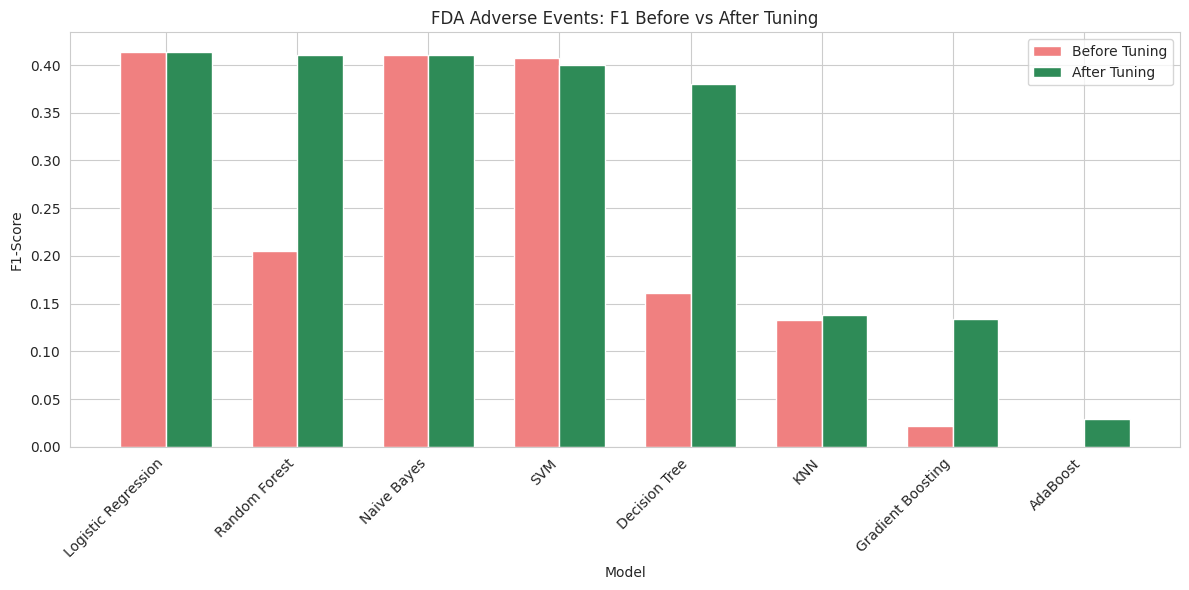

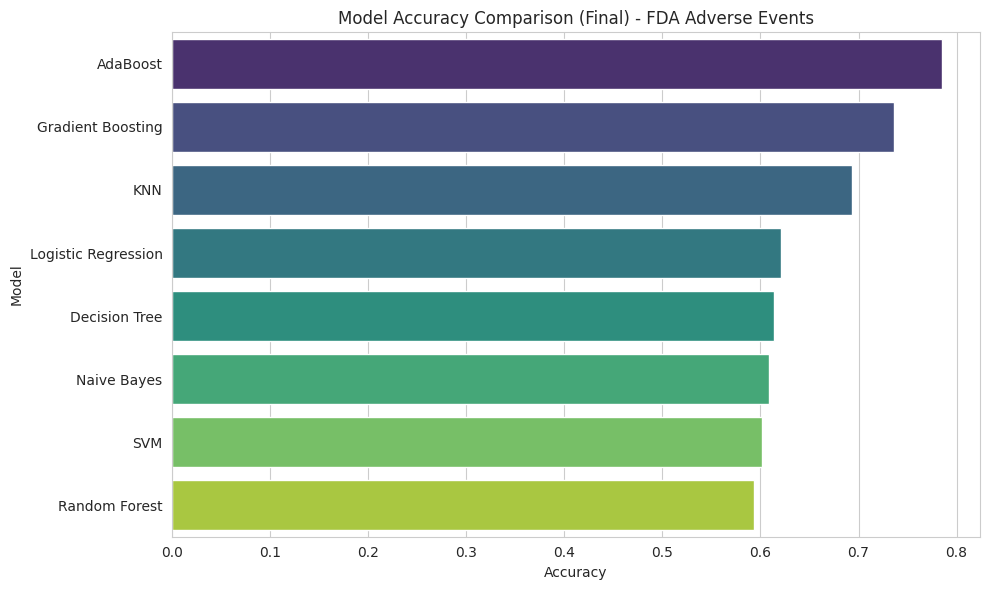

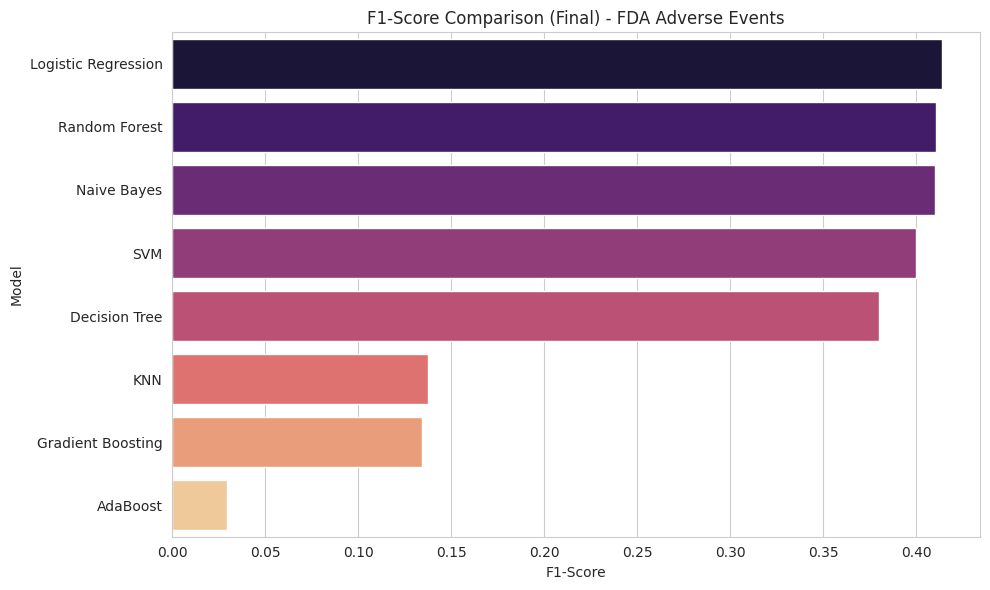

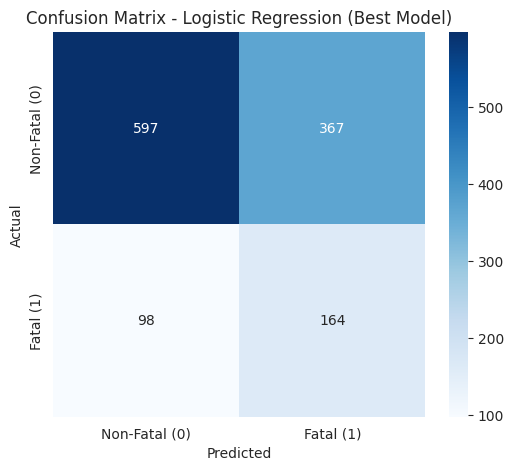

[[597 367]
 [ 98 164]]


In [33]:
# ============================================
# STEP 17: All Final Visualizations
# ============================================
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df)); width = 0.35
plt.bar(x - width/2, comparison_df['F1-Score (Before)'], width, label='Before Tuning', color='lightcoral')
plt.bar(x + width/2, comparison_df['F1-Score (After)'], width, label='After Tuning', color='seagreen')
plt.xlabel('Model'); plt.ylabel('F1-Score'); plt.title('FDA Adverse Events: F1 Before vs After Tuning')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right'); plt.legend(); plt.tight_layout()
plt.savefig('fda_before_after_tuning_f1.png', dpi=150); plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=final_df.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Model Accuracy Comparison (Final) - FDA Adverse Events'); plt.tight_layout()
plt.savefig('fda_accuracy_comparison.png', dpi=150); plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Model', data=final_df.sort_values(by='F1-Score', ascending=False), palette='magma')
plt.title('F1-Score Comparison (Final) - FDA Adverse Events'); plt.tight_layout()
plt.savefig('fda_f1_comparison.png', dpi=150); plt.show()

best_model = final_models['Logistic Regression']
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fatal (0)', 'Fatal (1)'], yticklabels=['Non-Fatal (0)', 'Fatal (1)'])
plt.title('Confusion Matrix - Logistic Regression (Best Model)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.savefig('fda_confusion_matrix.png', dpi=150); plt.show()
print(cm)

In [34]:
# ============================================
# STEP 18: Save All Models, Scaler, Encoders, Feature Info
# ============================================
local_dir = 'saved_models/notebook4'
drive_dir = '/content/drive/MyDrive/Machine Learning Projects/saved_models/notebook4'
os.makedirs(local_dir, exist_ok=True)
os.makedirs(drive_dir, exist_ok=True)

for name, model in final_models.items():
    filename = 'fda_' + name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, os.path.join(local_dir, filename))
    joblib.dump(model, os.path.join(drive_dir, filename))
    print(f"Saved: {filename}")

joblib.dump(scaler, os.path.join(local_dir, 'fda_scaler.pkl'))
joblib.dump(scaler, os.path.join(drive_dir, 'fda_scaler.pkl'))
joblib.dump(le_sex, os.path.join(local_dir, 'fda_sex_encoder.pkl'))
joblib.dump(le_sex, os.path.join(drive_dir, 'fda_sex_encoder.pkl'))
joblib.dump(le_fatal, os.path.join(local_dir, 'fda_fatal_encoder.pkl'))
joblib.dump(le_fatal, os.path.join(drive_dir, 'fda_fatal_encoder.pkl'))

feature_info = pd.DataFrame({'min': X.min(), 'max': X.max(), 'mean': X.mean(), 'dtype': X.dtypes})
feature_info.to_csv(os.path.join(local_dir, 'fda_feature_info.csv'))
feature_info.to_csv(os.path.join(drive_dir, 'fda_feature_info.csv'))

print("\nAll models, scaler, encoders, feature info saved (local + Drive).")

Saved: fda_logistic_regression.pkl
Saved: fda_knn.pkl
Saved: fda_naive_bayes.pkl
Saved: fda_decision_tree.pkl
Saved: fda_random_forest.pkl
Saved: fda_svm.pkl
Saved: fda_gradient_boosting.pkl
Saved: fda_adaboost.pkl

All models, scaler, encoders, feature info saved (local + Drive).


In [35]:
print(X_train_scaled.shape)

(4904, 34)


In [36]:
print(final_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.620718   0.308851  0.625954  0.413619  0.670037
4        Random Forest  0.592985   0.297436  0.664122  0.410862  0.657738
2          Naive Bayes  0.608483   0.302536  0.637405  0.410319  0.653877
5                  SVM  0.601142   0.294756  0.622137  0.400000  0.642536
3        Decision Tree  0.614192   0.289421  0.553435  0.380079  0.627469
1                  KNN  0.693312   0.172414  0.114504  0.137615  0.503726
6    Gradient Boosting  0.736542   0.225225  0.095420  0.134048  0.608292
7             AdaBoost  0.784666   0.400000  0.015267  0.029412  0.668509


In [37]:
# ============================================
# DOCUMENTATION: Individual Confusion Matrix, ROC, and PR curves per model
# ============================================
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
import os

os.makedirs('doc_images', exist_ok=True)

def save_individual_cms(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        y_pred = model.predict(X_test_scaled)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=True)
        ax.set_title(f"Confusion Matrix \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_cm_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

def save_individual_rocs(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
        ax.set_title(f"ROC Curve \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_roc_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

def save_individual_prs(model_dict, stage, prefix):
    for name, model in model_dict.items():
        fig, ax = plt.subplots(figsize=(6, 5))
        PrecisionRecallDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
        ax.set_title(f"Precision-Recall Curve \u2013 {name} ({stage})", fontsize=11)
        plt.tight_layout()
        safe_name = name.lower().replace(' ', '_')
        plt.savefig(f'doc_images/{prefix}_pr_{stage}_{safe_name}.png', dpi=150)
        plt.close(fig)

PREFIX = "fda"

# Baseline (8 models x 3 chart types = 24 images)
save_individual_cms(models, "baseline", PREFIX)
save_individual_rocs(models, "baseline", PREFIX)
save_individual_prs(models, "baseline", PREFIX)

# Final/tuned models (8 models x 3 chart types = 24 images)
save_individual_cms(final_models, "tuned", PREFIX)
save_individual_rocs(final_models, "tuned", PREFIX)
save_individual_prs(final_models, "tuned", PREFIX)

print(f"Done. Total images saved: {len(os.listdir('doc_images'))}")

Done. Total images saved: 48


In [38]:
import shutil
from google.colab import files

shutil.make_archive('fda_doc_images_48', 'zip', 'doc_images')
files.download('fda_doc_images_48.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>